# Lecture 10 - (12/03/2026)

Today's Topics:

- Community Detection
- Subgraphs
- Pathing

## Community Detection

Community detection algorithms group nodes into non-overlapping clusters. To break it down a bit more, let’s use an example. Below is a simple undirected graph with seven nodes.

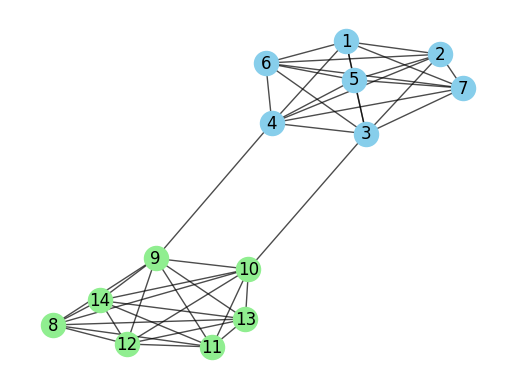

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.Graph()

cluster1 = range(1, 8)
cluster2 = range(8, 15)

G.add_nodes_from(cluster1)
G.add_nodes_from(cluster2)

for i in cluster1:
    for j in cluster1:
        if i < j:
            G.add_edge(i, j)

for i in cluster2:
    for j in cluster2:
        if i < j:
            G.add_edge(i, j)

cross_edges = [(3, 10), (4, 9)]
G.add_edges_from(cross_edges)

pos = nx.spring_layout(G, seed=42)
nx.draw_networkx_nodes(G, pos, nodelist=cluster1, node_color='skyblue')
nx.draw_networkx_nodes(G, pos, nodelist=cluster2, node_color='lightgreen')
nx.draw_networkx_edges(G, pos, width=1.0, alpha=0.7)
nx.draw_networkx_labels(G, pos)

plt.axis('off')
plt.show()

Just by looking at this graph, you can probably spot two clear communities. Nodes 1-7 form one group, while nodes 8-14 make up the other. It was pretty easy for us to see these clusters visually, but our method for choosing which nodes belong to which group might vary.

Here are some strategies that we can use to construct these communities

- Remove weak ties: The edge between 4 and 9, and 3 and 10, acts as a natural break point to separate the two groups.
- Preserve strong ties: Nodes 1-7 and nodes 8-14 are tightly connected, suggesting strong ties within each group.
- Distance: How far apart two nodes are might tell us whether they belong in the same group or not.

#### [Girvan Newman](https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.community.centrality.girvan_newman.html)

The Girvan-Newman algorithm is one of the most popular and effective community detection methods out there. It works by removing edges that connect nodes with high betweenness centrality. 

Using this approach in Python is a bit more involved than some others, but it’s highly effective when done right.

In [2]:
comp = nx.community.girvan_newman(G)

Instead of specifying how many communities you want, NetworkX just removes edges one by one in each step. As it does, the number of communities automatically grows as you go along.



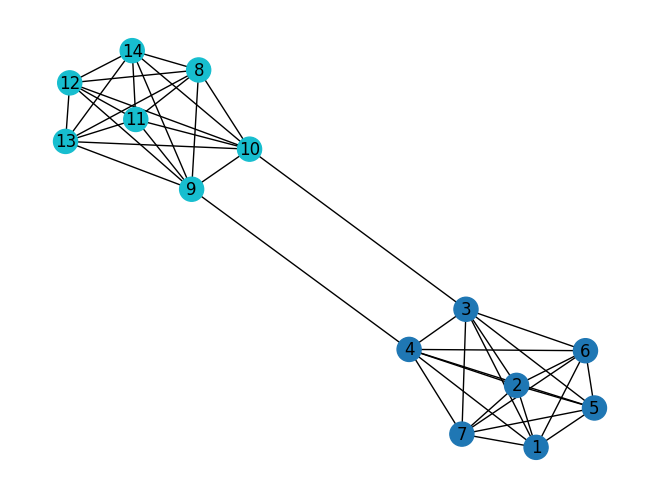

In [3]:
first_level_communities = tuple(sorted(c) for c in next(comp))

community_map = {}
for i, com in enumerate(first_level_communities):
    for node in com:
        community_map[node] = i

colors = [community_map[node] for node in G.nodes()]
pos = nx.spring_layout(G)
nx.draw(G, pos, node_color=colors, with_labels=True, cmap=plt.cm.tab10, node_size=300)

#### [K-clique](https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.community.kclique.k_clique_communities.html#networkx.algorithms.community.kclique.k_clique_communities)

The K-clique method is a way to find tightly connected groups of nodes in large networks. A clique is basically a subgraph where every node is connected to every other node in that group. You can think of cliques as groups where everyone knows everyone. Above, you can see examples of cliques between nodes 1-7 and with nodes 8-14.

To use k-clique in networkx, all you need to do is specify the size of the clique k.

In [11]:
cliques = nx.community.k_clique_communities(G, 7)

Unlike other community detection methods, this one only finds a community when a group of nodes forms a fully connected clique. In other words, the nodes need to be completely connected before they’re considered part of the same community.

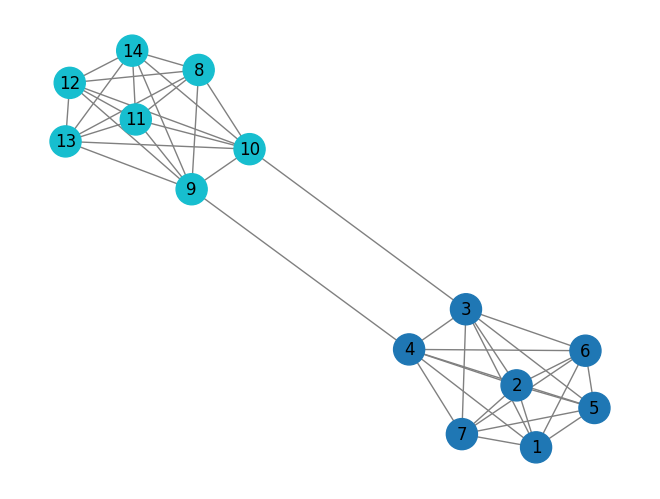

In [12]:
community_map = {}
for i, com in enumerate(list(cliques)):
    for node in com:
        if node not in community_map:
            community_map[node] = i

colors = [community_map.get(node, -1) for node in G.nodes()]

nx.draw(
    G,
    pos,
    node_color=colors,
    cmap=plt.cm.tab10,
    with_labels=True,
    node_size=500,
    edge_color='gray'
)

#### [Tree partitioning](https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.community.lukes.lukes_partitioning.html#networkx.algorithms.community.lukes.lukes_partitioning)

Tree partitioning works by grouping nodes into clusters based on a mix of node and edge weights. The catch is that this approach only works if the network is set up like a tree — meaning it has a hierarchical structure. One of the most common algorithms for this is Lukes partitioning.

In [ ]:
tree = nx.community.lukes_partitioning(G, 7)

When using networkx, the algorithm needs a cut-off point, `max_size`, which means the partition can’t go over a certain size.

## Finding Subgraphs

A subgraph is just a smaller part of a larger graph. You can think of it as a mini version of the full graph, where we’re interested in seeing specific patterns or groups of nodes.

Subgraphs are like little windows into the overall network. They’re the building blocks that reveal how the network is structured.

There are many ways to extract subgraphs, but the most common method is by counting them based on their structure. Essentially, a subgraph is identified by the number of nodes it contains, which could range from just a couple to hundreds. To keep things simple, we often stick to smaller numbers, like three nodes - which is why triads come into play.

Finding subgraphs falls into what we call an "NP-complete" problem (you can read more on the subgraph isomorphism problem). In plain terms: the more nodes you want to include in a subgraph, the more complex it becomes, and the number of combinations skyrockets. This means that analyzing larger subgraphs takes longer. Here’s a quick table showing how the number of possible subgraphs increases as the number of nodes grows:

| No. Nodes | No. Combinations (undirected) | No. Combinations (directed) |
|-----------|-------------------------------|-----------------------------|
| 3         | 2                             | 13                          |
| 4         | 6                             | 199                         |
| 5         | 21                            | 9,364                       |
| 6         | 112                           | 1,530,843                   |

If you’re using networkx, there’s a handy function for counting triads in a network. Just remember that this works best if your network has directed edges. Here’s how you can use it with a random graph generator:

{'003': 7310, '012': 7651, '102': 781, '021D': 657, '021U': 695, '021C': 1412, '111D': 301, '111U': 290, '030T': 258, '030C': 87, '201': 43, '120D': 27, '120U': 24, '120C': 53, '210': 11, '300': 0}


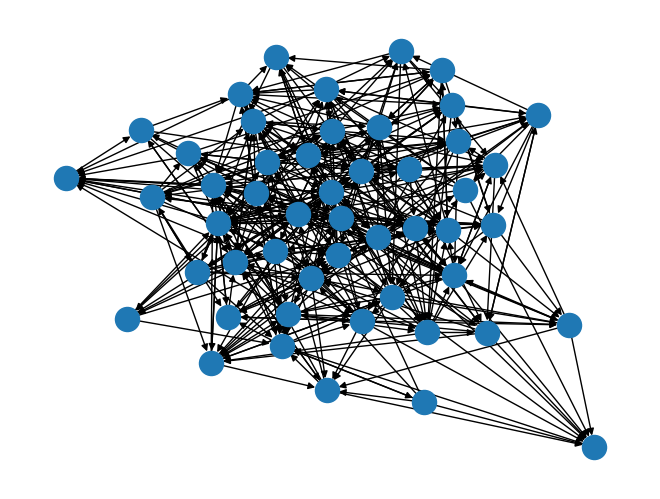

In [35]:
G = nx.fast_gnp_random_graph(n=50, p=0.15, directed=True)
print(nx.triadic_census(G))
nx.draw(G)

So, what does this give you? The result is a dictionary where each key represents a specific type of triad, and the value tells you how many times that triad shows up in your network. If you’re curious about what these codes mean, use this table as reference

| Triad Type | Description                          |
|------------|--------------------------------------|
| 003        | Empty triad (no edges)               |       
| 012        | Single directed edge                 |       
| 102        | One mutual dyad                       |       
| 021D       | Downward chain (i → j → k)          |       
| 021U       | Upward chain (i ← j ← k)            |      
| 021C       | Cycle of length 3 with one edge      |       
| 111D       | One mutual + one down edge           |       
| 111U       | One mutual + one up edge             |      
| 030T       | Transitive triad (i → j → k and i → k)|       
| 030C       | Cyclic triad (i → j → k → i)        |       
| 201        | Two mutual dyads                     |       
| 120D       | Downward triad (mutual + outgoing)   |       
| 120U       | Upward triad (mutual + incoming)     |       
| 120C       | Cyclic triad (mutual + cycle)        |       
| 210        | Three edges, 2 mutuals               |       
| 300        | Complete triad (3 mutual edges)      |       

![image](https://www.researchgate.net/publication/328894419/figure/fig2/AS:692307795922946@1542070449475/The-sixteen-isomorphism-classes-of-triad-census-for-directed-networks-D-stands-for.png)

Applications:

Subgraphs are a pretty big deal in network science. Here are a few ways they can help you analyse complex networks:

- Motifs

Motifs are subgraphs that appear either more or less often than you’d expect by chance. The idea is to count the subgraphs, compare the counts to a random baseline, and see which structures stand out.

- Cliques

They’re groups of tightly connected nodes. Subgraph analysis can help you find these cliques by spotting specific patterns. For example, the triad labeled 300 represents a fully connected subgraph.

- Path Finding

Subgraph analysis is also useful for tracking connections between nodes in a network. This is great if you’re trying to find simple paths or cycles within the network. These substructures help you figure out how nodes link up from point A to point B.

## Path Finding

Pathfinding is a handy method for getting from one point to another, and it’s used in loads of different scenarios where you want to minimise the number of connections without spending too much. This is especially helpful when studying networks, as it helps us uncover important connections between different nodes.



Pathfinding shows up in a bunch of everyday applications. Here are just two examples of where you might come across it.

Games: 

- From maze-solving to MMORPGs, pathfinding plays a big part. In maze-solving, for instance, the aim is often to guide a character or agent through a virtual space without bumping into walls or other players. Since computers are so efficient at finding paths, game developers sometimes have to make them a bit "dumber" to make things feel more realistic. This can be done by adding a bit of random noise, so it looks like the computer is making small mistakes now and again.

GPS:

- An obvious use of pathfinding is in GPS, which guide people through maps from their current location to their destination. In this case, nodes could represent junctions or roundabouts, and edges would be the roads. Of course, GPS routing is far more complex than this, but it’s likely that some form of pathfinding algorithm is involved.

There are loads of ways to implement pathfinding, but the general idea is to find the shortest path between two nodes. For simplicity’s sake, this post will focus on two key algorithms. They are:

#### Dijkstra

Dijkstra’s algorithm is the foundation for almost all pathfinding methods. The basic idea is to find the shortest path to the destination by starting at the source node and moving to a neighbouring node, provided it brings you closer to your goal. This process repeats until the destination is reached.

If you’re using NetworkX, you can implement this in various ways, but the simplest method is to use the following, making sure the method is explicitly set to 'dijkstra'.

In [ ]:
import requests
import networkx as nx
from math import sqrt

url = "https://data.ny.gov/resource/i9wp-a4ja.json?$limit=5000"
data = requests.get(url).json()

stations = {}
for record in data:
    name = record.get("stop_name")
    if not name:
        continue
    name = name.strip()
    lat = record.get("entrance_latitude")
    lon = record.get("entrance_longitude")
    if not lat or not lon:
        continue
    lines = record.get("daytime_routes", "").split()
    if name not in stations:
        stations[name] = {"lat": float(lat), "lon": float(lon), "lines": lines}

G = nx.Graph()
for name, attr in stations.items():
    G.add_node(name, **attr)

station_list = list(G.nodes(data=True))
for i, (s1, d1) in enumerate(station_list):
    for s2, d2 in station_list[i+1:]:
        if set(d1["lines"]) & set(d2["lines"]):
            dx = d1["lat"] - d2["lat"]
            dy = d1["lon"] - d2["lon"]
            distance = sqrt(dx*dx + dy*dy)
            G.add_edge(s1, s2, weight=distance)

print("Stations (nodes):", G.number_of_nodes())
print("Connections (edges):", G.number_of_edges())

Stations (nodes): 372
Connections (edges): 8237
['Atlantic Av-Barclays Ctr', 'Union St', '4 Av-9 St', 'Prospect Av', '25 St', '36 St', '45 St', '53 St', '59 St', 'Bay Ridge Av', '77 St', '86 St', 'Bay Ridge-95 St', '21 St-Queensbridge', 'Roosevelt Island', 'Lexington Av/63 St', '57 St', '47-50 Sts-Rockefeller Ctr', '42 St-Bryant Pk/5 Av', '34 St-Herald Sq', '34 St-Herald Square', '23 St', '14 St/6 Av', 'Broadway-Lafayette St/Bleecker St', 'Grand St', '2 Av', 'Delancey St-Essex St', 'East Broadway', 'York St', 'Bergen St', 'Carroll St', 'Smith-9 Sts', '7 Av', '15 St-Prospect Park', 'Fort Hamilton Pkwy', 'Church Av', 'Ditmas Av', '18 Av', 'Avenue I', 'Bay Pkwy', 'Avenue N', 'Avenue P', 'Kings Hwy', 'Avenue U', 'Avenue X', 'Neptune Av', 'Inwood-207 St', 'Dyckman St', '190 St', '181 St']


In [45]:
path = nx.dijkstra_path(G, "Delancey St-Essex St", "68 St-Hunter College", weight="weight")
print(path)

['Delancey St-Essex St', 'Lexington Av/51-53 Sts', '68 St-Hunter College']


#### A* (A star)

A* is a variation of Dijkstra’s algorithm, but it’s more commonly used in game development because it’s faster and less complex, as it looks at fewer nodes. The key difference is that A* uses a specific heuristic to better estimate the distance (or cost/weight) between nodes. This could be based on a complex in-game metric or something simpler like the Manhattan or Euclidean distance between two points.

To use A* in NetworkX, you’ll need to define your distance heuristic function. The NetworkX documentation provides a great example of using Euclidean distance to calculate the cost.

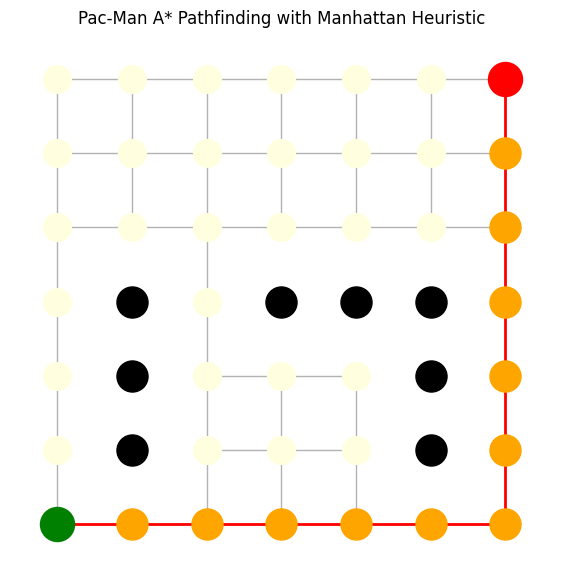

Path found: [(0, 0), (1, 0), (2, 0), (3, 0), (4, 0), (5, 0), (6, 0), (6, 1), (6, 2), (6, 3), (6, 4), (6, 5), (6, 6)]


In [48]:
import networkx as nx
import matplotlib.pyplot as plt

width, height = 7, 7
G = nx.grid_2d_graph(width, height)

walls = [(1,1), (1,2), (1,3), (3,3), (4,3), (5,1), (5,2), (5,3)]
G.remove_nodes_from(walls)

start = (0,0)
goal = (6,6)

def manhattan(a, b):
    return abs(a[0]-b[0]) + abs(a[1]-b[1])

path = nx.astar_path(G, start, goal, heuristic=manhattan)

pos = {node: node for node in G.nodes()}
plt.figure(figsize=(7,7))

nx.draw_networkx_nodes(G, pos, node_color='lightyellow', node_size=400)
nx.draw_networkx_edges(G, pos, alpha=0.3)

wall_x = [x for x, y in walls]
wall_y = [y for x, y in walls]
plt.scatter(wall_x, wall_y, s=500, c='black')

path_edges = list(zip(path, path[1:]))
nx.draw_networkx_nodes(G, pos, nodelist=path, node_color='orange', node_size=500)
nx.draw_networkx_edges(G, pos, edgelist=path_edges, edge_color='red', width=2)

nx.draw_networkx_nodes(G, pos, nodelist=[start], node_color='green', node_size=600)
nx.draw_networkx_nodes(G, pos, nodelist=[goal], node_color='red', node_size=600)

plt.title("Pac-Man A* Pathfinding with Manhattan Heuristic")
plt.axis('off')
plt.show()

print("Path found:", path)